# Telecom customer churn - comparing five classifiers

Assignment 2, Machine Learning (S2-25_AIMLCZG565).

Dataset: the BigML telecom churn extract (the "Churn in Telecom's dataset" listing on Kaggle),
which ships as two CSVs totalling 3,333 customers and 19 predictors. The label is `Churn`,
a flag for whether the customer left. The aim here is to fit the five classifiers the brief
asks for on one shared preprocessing pipeline, score them on the same held-out split, and
save the fitted pipelines for the Streamlit app to reload.

In [1]:
import sys

sys.path.insert(0, "..")  # churn_features.py lives at the repo root, next to app.py

import joblib
import matplotlib.pyplot as plt
import pandas as pd

from churn_features import MODEL_FILES, TARGET, build_preprocessor, load_raw, split_target

pd.set_option("display.width", 140)

## 1. Loading the data

The download is already cut into a train and a test file, but I would rather do the split
myself so that it is stratified and reproducible from this notebook alone. So the two files
get stacked back together first.

In [2]:
churn = load_raw("../data")
churn.shape

(3333, 20)

In [3]:
churn.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [4]:
churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   3333 non-null   str    
 1   Account length          3333 non-null   int64  
 2   Area code               3333 non-null   int64  
 3   International plan      3333 non-null   str    
 4   Voice mail plan         3333 non-null   str    
 5   Number vmail messages   3333 non-null   int64  
 6   Total day minutes       3333 non-null   float64
 7   Total day calls         3333 non-null   int64  
 8   Total day charge        3333 non-null   float64
 9   Total eve minutes       3333 non-null   float64
 10  Total eve calls         3333 non-null   int64  
 11  Total eve charge        3333 non-null   float64
 12  Total night minutes     3333 non-null   float64
 13  Total night calls       3333 non-null   int64  
 14  Total night charge      3333 non-null   float64
 15

In [5]:
churn.isna().sum().sum()

np.int64(0)

Nothing is missing anywhere, so no imputation is needed in the pipeline.

## 2. How balanced is the label?

In [6]:
counts = churn[TARGET].value_counts()
pd.DataFrame({"customers": counts, "share": (counts / len(churn)).round(4)})

,customers,share
Churn,,
False,2850,0.8551
True,483,0.1449


Only about one customer in seven churned. A model that simply predicts "nobody leaves"
would already score 85.5% accuracy, so accuracy on its own tells us very little here.
Recall, F1 and MCC are the columns worth reading in the comparison table.

## 3. Which columns are actually categorical?

Sorting by the number of distinct values makes the odd ones out obvious.

In [7]:
churn.drop(columns=[TARGET]).nunique().sort_values()

International plan           2
Voice mail plan              2
Area code                    3
Customer service calls      10
Total intl calls            21
Number vmail messages       46
State                       51
Total day calls            119
Total night calls          120
Total eve calls            123
Total intl charge          162
Total intl minutes         162
Account length             212
Total night charge         933
Total eve charge          1440
Total night minutes       1591
Total eve minutes         1611
Total day charge          1667
Total day minutes         1667
dtype: int64

Two things worth acting on:

- `Area code` is stored as an integer but only ever holds 408, 415 or 510. It is a region
  label, not a quantity, so scaling it would be meaningless - it needs one-hot encoding.
- `International plan` and `Voice mail plan` are yes/no. Turning them into dummies would add
  a perfectly redundant second column each, so they are just mapped to 0/1.

`State` has 51 levels and is one-hot encoded; the remaining 15 columns are genuinely
continuous and get standardised. That is exactly the split written down in `churn_features.py`.

## 4. A quirk in the billing columns

Before modelling, the four `charge` columns looked suspicious next to the four `minutes`
columns, so I checked the ratio between them.

In [8]:
periods = [
    ("day", "Total day minutes", "Total day charge"),
    ("evening", "Total eve minutes", "Total eve charge"),
    ("night", "Total night minutes", "Total night charge"),
    ("international", "Total intl minutes", "Total intl charge"),
]

tariffs = []
for label, minutes, charge in periods:
    billed = churn[churn[minutes] > 0]
    rate = billed[charge] / billed[minutes]
    tariffs.append({
        "period": label,
        "lowest rate": round(rate.min(), 4),
        "highest rate": round(rate.max(), 4),
        "correlation": round(churn[minutes].corr(churn[charge]), 6),
    })

pd.DataFrame(tariffs)

,period,lowest rate,highest rate,correlation
0,day,0.1692,0.1705,1.000000
1,evening,0.0849,0.0851,1.000000
2,night,0.0448,0.0451,0.999999
3,international,0.2682,0.2727,0.999993


Each charge column is just its minutes column multiplied by a flat per-minute tariff -
17.0c for day, 8.5c for evening, 4.5c for night, 27.0c for international - and the
correlations are 1.0 to six decimal places. So four of the fifteen numeric predictors carry
no information the model does not already have.

I am leaving them in, since feature selection is not part of this brief and the tree-based
models are unaffected by it. It does matter for one model though: Naive Bayes assumes the
predictors are conditionally independent given the class, and here four pairs are perfectly
dependent by construction. That is a concrete reason to expect it to trail the others rather
than a generic "Naive Bayes is naive" hand-wave.

## 5. What actually separates the churners?

In [9]:
by_calls = churn.groupby("Customer service calls")[TARGET].agg(customers="size", churned="sum")
by_calls["churn rate"] = (by_calls["churned"] / by_calls["customers"]).round(3)
by_calls

,customers,churned,churn rate
Customer service calls,,,
0,697,92,0.132
1,1181,122,0.103
2,759,87,0.115
3,429,44,0.103
4,166,76,0.458
5,66,40,0.606
6,22,14,0.636
7,9,5,0.556
8,2,1,0.500


This is the sharpest signal in the dataset. Up to three support calls the churn rate sits
between 10% and 13%, then it jumps past 45% from the fourth call onward. It is a step, not a
gradient, which suggests the tree-based models should do well - a single threshold at
`Customer service calls >= 4` captures most of it, whereas logistic regression has to
approximate the step with a straight line.

In [10]:
for column in ["International plan", "Voice mail plan"]:
    summary = churn.groupby(column)[TARGET].agg(customers="size", churned="sum")
    summary["churn rate"] = (summary["churned"] / summary["customers"]).round(3)
    print(column)
    print(summary, "\n")

International plan
                    customers  churned  churn rate
International plan                                
No                       3010      346       0.115
Yes                       323      137       0.424 

Voice mail plan
                 customers  churned  churn rate
Voice mail plan                                
No                    2411      403       0.167
Yes                    922       80       0.087 



Customers on the international plan churn at 42.4% against 11.5% for everyone else - a big
gap, though only 323 customers are on that plan. The voice mail plan runs the other way and
more weakly.

## 6. Train / test split

80/20, stratified so the 14.5% churn rate survives in both halves. The seed is the tail of my
student ID so the run is repeatable.

In [11]:
from sklearn.model_selection import train_test_split

SEED = 5989

X, y = split_target(churn)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print("train", X_train.shape, "churn rate", round(y_train.mean(), 4))
print("test ", X_test.shape, "churn rate", round(y_test.mean(), 4))

train (2666, 19) churn rate 0.1448
test  (667, 19) churn rate 0.1454


## 7. Fitting the models

Every model sits behind the same `ColumnTransformer`, wrapped in a `Pipeline`. That way the
scaling is fitted on the training fold only (no leakage into the test set), the comparison is
like-for-like, and each saved `.pkl` is self-contained - the app can hand it a raw dataframe
without repeating any preprocessing.

The brief lists five models; I have added gradient boosting as a sixth so there is a second
ensemble to compare the random forest against. All are left at library defaults, because
tuning only some of them would make the table meaningless.

In [12]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

candidates = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "Decision Tree": DecisionTreeClassifier(random_state=SEED),
    "kNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Random Forest (Ensemble)": RandomForestClassifier(random_state=SEED),
    "Gradient Boosting (Ensemble)": GradientBoostingClassifier(random_state=SEED),
}

fitted = {}
for name, estimator in candidates.items():
    pipeline = Pipeline([("prep", build_preprocessor()), ("model", estimator)])
    pipeline.fit(X_train, y_train)
    fitted[name] = pipeline
    print("fitted", name)

fitted Logistic Regression
fitted Decision Tree
fitted kNN
fitted Naive Bayes


fitted Random Forest (Ensemble)


fitted Gradient Boosting (Ensemble)


## 8. Scoring

AUC needs the probability of the positive class rather than the hard prediction, so it comes
from `predict_proba` while the other five come from `predict`.

In [13]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)


def score(pipeline, features, labels):
    predicted = pipeline.predict(features)
    churn_probability = pipeline.predict_proba(features)[:, 1]
    return {
        "Accuracy": accuracy_score(labels, predicted),
        "AUC": roc_auc_score(labels, churn_probability),
        "Precision": precision_score(labels, predicted, zero_division=0),
        "Recall": recall_score(labels, predicted),
        "F1": f1_score(labels, predicted),
        "MCC": matthews_corrcoef(labels, predicted),
    }


leaderboard = (
    pd.DataFrame({name: score(pipeline, X_test, y_test) for name, pipeline in fitted.items()})
    .T.round(4)
    .sort_values("F1", ascending=False)
)
leaderboard

,Accuracy,AUC,Precision,Recall,F1,MCC
Gradient Boosting (Ensemble),0.9595,0.9190,0.9605,0.7526,0.8439,0.8291
Decision Tree,0.9280,0.8510,0.7579,0.7423,0.7500,0.7080
Random Forest (Ensemble),0.9400,0.9096,0.9524,0.6186,0.7500,0.7393
kNN,0.8861,0.7613,0.8182,0.2784,0.4154,0.4354
Naive Bayes,0.6027,0.6401,0.2143,0.6495,0.3223,0.1734
Logistic Regression,0.8636,0.8217,0.5833,0.2165,0.3158,0.2967


## 9. Reading the table

In [14]:
baseline = 1 - y_test.mean()
print(f"predict-nobody-churns accuracy: {baseline:.4f}")
print(f"best F1: {leaderboard['F1'].idxmax()}")
print(f"best recall: {leaderboard['Recall'].idxmax()}")

predict-nobody-churns accuracy: 0.8546
best F1: Gradient Boosting (Ensemble)
best recall: Gradient Boosting (Ensemble)


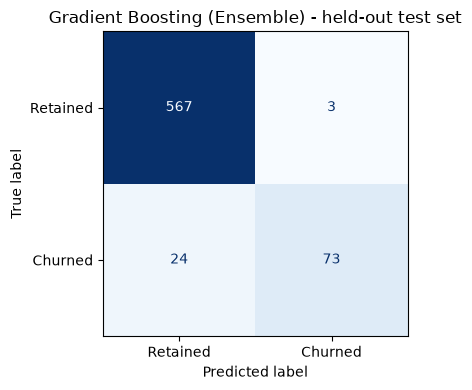

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

best = leaderboard["F1"].idxmax()

figure, axes = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_estimator(
    fitted[best], X_test, y_test,
    display_labels=["Retained", "Churned"], cmap="Blues", colorbar=False, ax=axes,
)
axes.set_title(f"{best} - held-out test set")
plt.tight_layout()
plt.show()

## 10. Saving the pipelines and the test split

The `.pkl` files feed the Streamlit app. `metrics_summary.csv` is written out too so the
comparison table in the README is copied from a file rather than retyped by hand.

For `test_data.csv` I export the original rows rather than the encoded matrix - the label
column is kept, and `Yes`/`No` and `True`/`False` stay as they were, so the file looks like
something a person would realistically upload. `coerce_schema` in the app puts the dtypes
back after `read_csv` guesses them.

In [16]:
for name, pipeline in fitted.items():
    joblib.dump(pipeline, f"{MODEL_FILES[name]}.pkl")

leaderboard.to_csv("metrics_summary.csv", index_label="Model")

holdout = churn.loc[X_test.index]
holdout.to_csv("../test_data.csv", index=False)

print("saved", len(MODEL_FILES), "pipelines")
print("test_data.csv:", holdout.shape, "churn rate", round(holdout[TARGET].mean(), 4))

saved 6 pipelines
test_data.csv: (667, 20) churn rate 0.1454


## 11. Where this lands

The ensembles win comfortably. The step-shaped relationship between support calls and churn,
plus the international-plan gap, is exactly the kind of structure a tree splits on directly
and a linear boundary has to approximate - which is what the gap between the tree-based
models and logistic regression in the table reflects.

Written-up observations per model are in the README at the repo root.